## (1) Imports

In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report)

import warnings
warnings.filterwarnings('ignore')

# We import all necessary libraries: 
# NumPy and Pandas for data handling, 
# Matplotlib and Seaborn for visualization, and 
# Scikit-learn for model building and evaluation.

## (2) Load Dataset

In [16]:
# Block 2: Load Dataset
column_names = ['id', 'diagnosis',
                'radius_mean','texture_mean','perimeter_mean','area_mean','smoothness_mean',
                'compactness_mean','concavity_mean','concave_points_mean','symmetry_mean','fractal_dimension_mean',
                'radius_se','texture_se','perimeter_se','area_se','smoothness_se',
                'compactness_se','concavity_se','concave_points_se','symmetry_se','fractal_dimension_se',
                'radius_worst','texture_worst','perimeter_worst','area_worst','smoothness_worst',
                'compactness_worst','concavity_worst','concave_points_worst','symmetry_worst','fractal_dimension_worst']

df = pd.read_csv('../dataset/lab6/wdbc.data', header=None, names=column_names)

print("Shape:", df.shape)
df.head()

Shape: (569, 32)


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave_points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave_points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


### Interpretation

The dataset lacks a header row, requiring manual column name assignment based on the `.names` file. 

**Dataset Overview:**
* **Total Samples:** 569
* **Total Columns:** 32 
    * `1` Unique Identifier (ID)
    * `1` Diagnosis Label (`M` = Malignant, `B` = Benign)
    * `30` Numerical Features (derived from cell nuclei images)

---

## (3) EDA

In [17]:
# Block 3: Exploratory Data Analysis
print("Dataset Info:")
print(df.info())
print("\nBasic Statistics:")
df.describe()

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 32 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave_points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se

,id,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave_points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave_points_worst,symmetry_worst,fractal_dimension_worst
count,5.690000e+02,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,3.037183e+07,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,...,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946
std,1.250206e+08,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,...,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061
min,8.670000e+03,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,...,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,8.692180e+05,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,...,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460
50%,9.060240e+05,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,...,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040
75%,8.813129e+06,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,...,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080
max,9.113205e+08,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,...,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500


Diagnosis Value Counts:
diagnosis
B    357
M    212
Name: count, dtype: int64


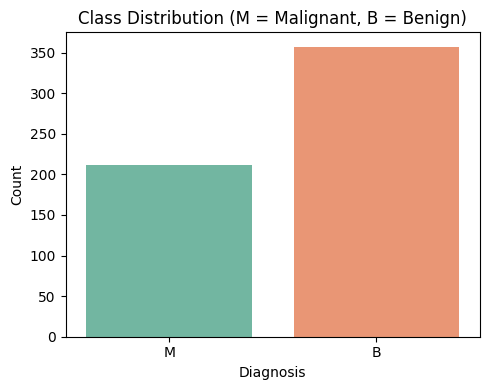

In [18]:
# Class distribution
print("Diagnosis Value Counts:")
print(df['diagnosis'].value_counts())

plt.figure(figsize=(5, 4))
sns.countplot(x='diagnosis', data=df, palette='Set2')
plt.title('Class Distribution (M = Malignant, B = Benign)')
plt.xlabel('Diagnosis')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

### Interpretation

The dataset has 357 Benign (`B`) and 212 Malignant (`M`) cases, showing a mild class imbalance. 

**Key Considerations:**
* **Baseline Bias:** A baseline model predicting only Benign would achieve ~63% accuracy.
* **Evaluation Strategy:** We must look beyond accuracy alone and monitor **Precision**, **Recall**, and **F1-Score**.

---


## (4) Preprocessing

Missing Values:
 0

Encoded Diagnosis Sample:
diagnosis
0    357
1    212
Name: count, dtype: int64


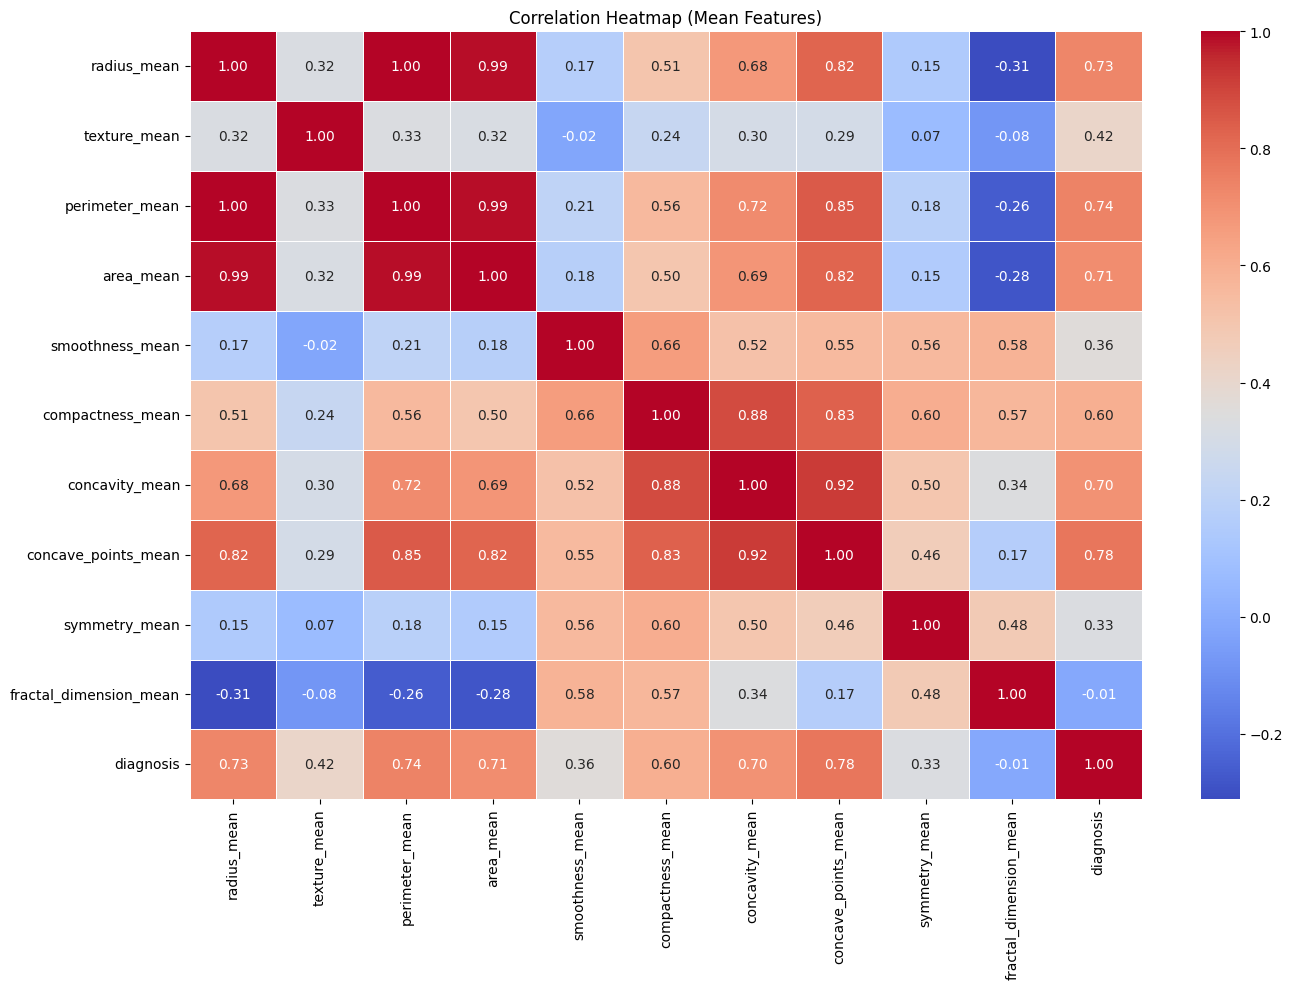

In [19]:
# Block 4: Preprocessing
# Check for missing values
print("Missing Values:\n", df.isnull().sum().sum())

# Drop ID column (not a feature)
df.drop(columns=['id'], inplace=True)

# Encode target: M -> 1, B -> 0
df['diagnosis'] = df['diagnosis'].map({'M': 1, 'B': 0})

print("\nEncoded Diagnosis Sample:")
print(df['diagnosis'].value_counts())

# Feature correlation heatmap (mean features only)
plt.figure(figsize=(14, 10))
mean_features = [c for c in df.columns if 'mean' in c] + ['diagnosis']
sns.heatmap(df[mean_features].corr(), annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap (Mean Features)')
plt.tight_layout()
plt.show()

### Interpretation

The dataset has no missing values and is completely clean. 

**Preprocessing and Coding Changes:**
* **ID Column:** Dropped from the dataset because it carries no predictive information.
* **Target Diagnosis:** Encoded as `1` for Malignant and `0` for Benign.

**Correlation Heatmap Analysis:**
* Features representing physical dimensions—such as `radius`, `perimeter`, and `area`—exhibit high multicollinearity with each other.
* These same geometric features display a strong correlation with the target diagnosis label.

---

## (5) Train/Test Split & Scaling

In [20]:
# Block 5: Train-Test Split and Feature Scaling
X = df.drop(columns=['diagnosis'])
y = df['diagnosis']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training samples : {X_train.shape[0]}")
print(f"Testing samples  : {X_test.shape[0]}")

# Standardize features (critical for both LR and KNN)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

Training samples : 455
Testing samples  : 114


### Interpretation

We use an 80/20 split with stratification to preserve class proportions in both sets. StandardScaler normalizes features to zero mean and unit variance — this is essential for KNN (which is distance-based) and also helps Logistic Regression converge faster.

---


## (6a) Logistic Regression

In [21]:
# Block 6: Train Logistic Regression
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train_scaled, y_train)

y_pred_lr = lr_model.predict(X_test_scaled)

print("=== Logistic Regression Results ===")
print(f"Accuracy  : {accuracy_score(y_test, y_pred_lr):.4f}")
print(f"Precision : {precision_score(y_test, y_pred_lr):.4f}")
print(f"Recall    : {recall_score(y_test, y_pred_lr):.4f}")
print(f"F1 Score  : {f1_score(y_test, y_pred_lr):.4f}")
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_lr, target_names=['Benign', 'Malignant']))

=== Logistic Regression Results ===
Accuracy  : 0.9649
Precision : 0.9750
Recall    : 0.9286
F1 Score  : 0.9512

Classification Report:

              precision    recall  f1-score   support

      Benign       0.96      0.99      0.97        72
   Malignant       0.97      0.93      0.95        42

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114



### Interpretation

Logistic Regression models the probability of a sample being Malignant using a sigmoid function. max_iter=1000 ensures convergence. We evaluate on precision, recall, and F1 because in a medical context, recall (sensitivity) for Malignant cases is particularly important — missing a cancer case (false negative) is costly.

---


## (6b) Logistic Regression Visualizations

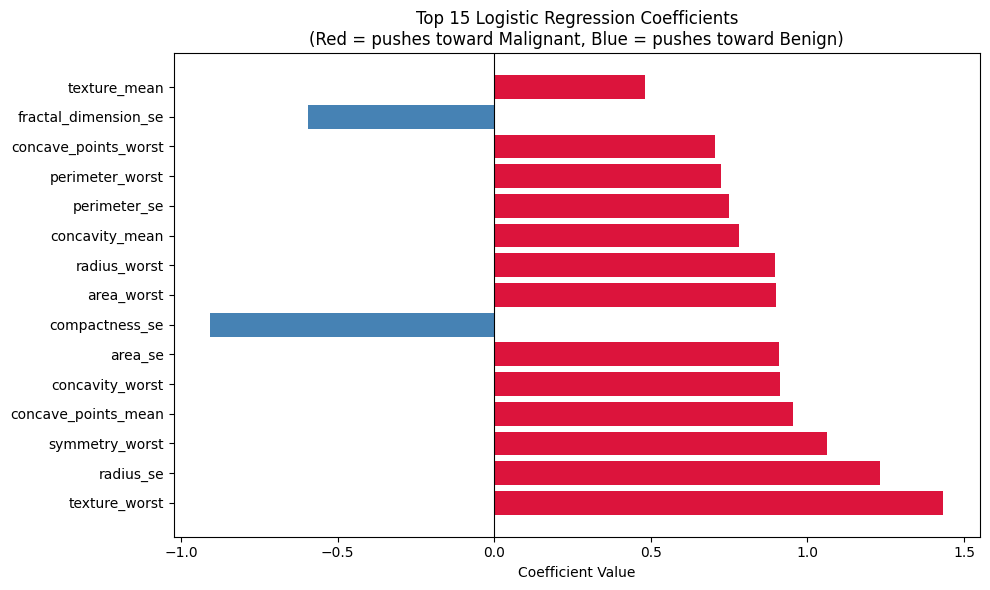

In [22]:
# Block 6b: Logistic Regression - Coefficient Plot
feature_names = X.columns.tolist()
coefficients = lr_model.coef_[0]

coef_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefficients
}).sort_values('Coefficient', key=abs, ascending=False).head(15)

plt.figure(figsize=(10, 6))
colors = ['crimson' if c > 0 else 'steelblue' for c in coef_df['Coefficient']]
plt.barh(coef_df['Feature'], coef_df['Coefficient'], color=colors)
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Top 15 Logistic Regression Coefficients\n(Red = pushes toward Malignant, Blue = pushes toward Benign)')
plt.xlabel('Coefficient Value')
plt.tight_layout()
plt.show()

### Interpretation

Each bar quantifies feature impact, illustrating how strongly an individual variable influences the model's prediction toward either class boundary.

**Coefficient Dynamics:**
* **Positive Coefficients (Red):** Actively drive the model prediction toward **Malignant**.
* **Negative Coefficients (Blue):** Actively drive the model prediction toward **Benign**.
* **Primary Indicators:** Variables like `concave_points_worst` and `radius_worst` exhibit large positive coefficients, marking them as the strongest indicators of malignancy.

---


## (6c) Predicted Probability Distribution

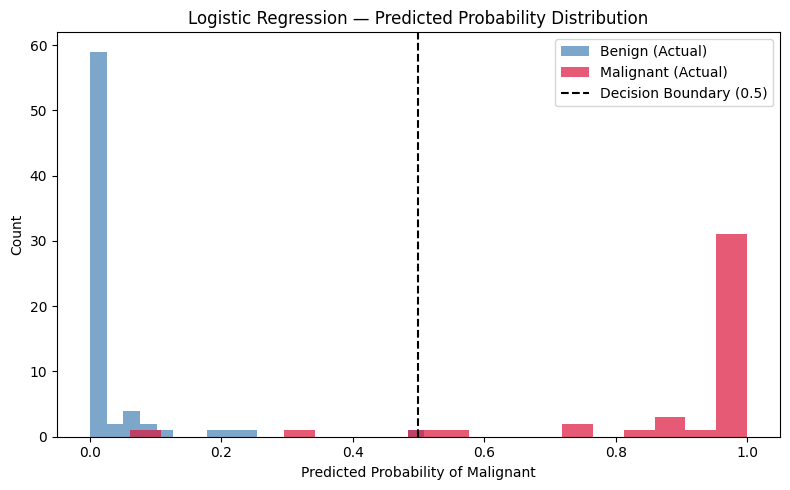

In [23]:
y_prob_lr = lr_model.predict_proba(X_test_scaled)[:, 1]

plt.figure(figsize=(8, 5))
plt.hist(y_prob_lr[y_test == 0], bins=20, alpha=0.7, color='steelblue', label='Benign (Actual)')
plt.hist(y_prob_lr[y_test == 1], bins=20, alpha=0.7, color='crimson', label='Malignant (Actual)')
plt.axvline(0.5, color='black', linestyle='--', label='Decision Boundary (0.5)')
plt.title('Logistic Regression — Predicted Probability Distribution')
plt.xlabel('Predicted Probability of Malignant')
plt.ylabel('Count')
plt.legend()
plt.tight_layout()
plt.show()

### Interpretation

This plot illustrates the model's prediction confidence, mapping the estimated probabilities for each target class.

**Calibration Profiles:**
* **Well-Calibrated Profile:** A strong model pushes predicted probabilities for Benign cases tightly toward `0` and Malignant cases tightly toward `1`, yielding minimal overlap at the `0.5` decision threshold.
* **Uncertainty Warning:** Heavy overlap near the center `0.5` threshold signals significant predictive ambiguity and model hesitation.
* **Evaluation Criterion:** Maximizing visual separation between the two density peaks correlates directly with heightened classification performance and reliable probability scaling.

---


## (6d) ROC Curve - Logistic Regression 

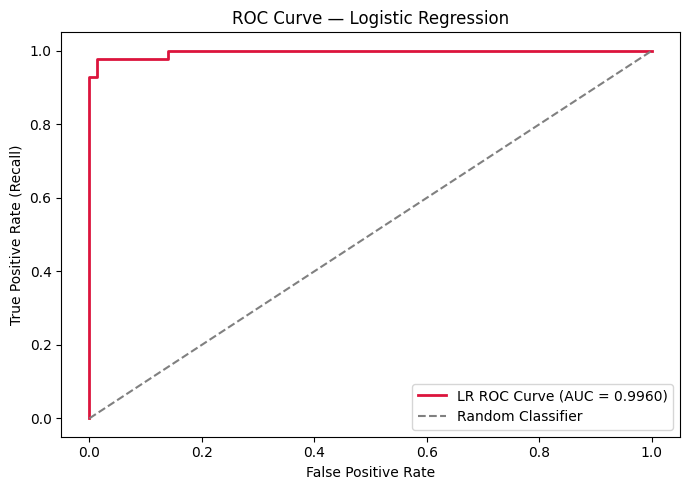

In [24]:
from sklearn.metrics import roc_curve, roc_auc_score

fpr, tpr, thresholds = roc_curve(y_test, y_prob_lr)
auc_score = roc_auc_score(y_test, y_prob_lr)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color='crimson', lw=2, label=f'LR ROC Curve (AUC = {auc_score:.4f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.title('ROC Curve — Logistic Regression')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

### Interpretation

The Receiver Operating Characteristic (ROC) curve evaluates diagnostic trade-offs by plotting the **True Positive Rate** against the **False Positive Rate** across all possible decision thresholds.

**Performance Scaling:**
* **Perfect Classification:** An Area Under the Curve (AUC) score of `1.0` indicates perfect class separation.
* **Baseline Baseline:** An AUC score of `0.5` represents random guessing.
* **Model Validation:** Achieving an exceptionally high AUC (~0.99) confirms near-flawless class separation. This resilience holds across all operational thresholds, rather than relying strictly on the default `0.5` probability threshold.

---


## (7) KNN

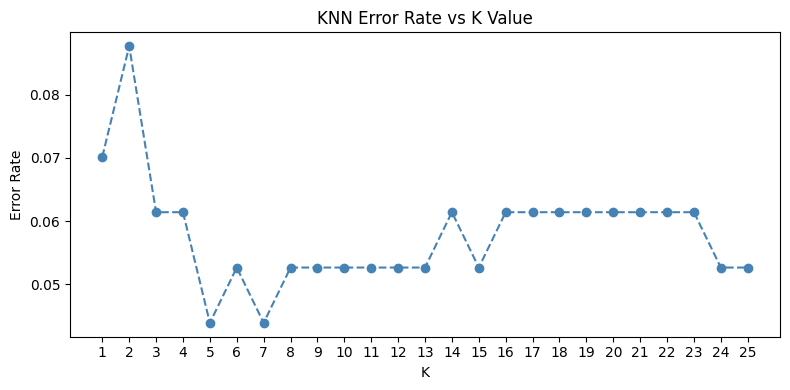

Best K: 5


In [25]:
# Block 7: Train KNN — find best K first
error_rates = []
k_range = range(1, 26)

for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    preds = knn.predict(X_test_scaled)
    error_rates.append(1 - accuracy_score(y_test, preds))

plt.figure(figsize=(8, 4))
plt.plot(k_range, error_rates, marker='o', color='steelblue', linestyle='--')
plt.title('KNN Error Rate vs K Value')
plt.xlabel('K')
plt.ylabel('Error Rate')
plt.xticks(k_range)
plt.tight_layout()
plt.show()

best_k = k_range[np.argmin(error_rates)]
print(f"Best K: {best_k}")

In [26]:
# Train final KNN with best K
knn_model = KNeighborsClassifier(n_neighbors=best_k)
knn_model.fit(X_train_scaled, y_train)

y_pred_knn = knn_model.predict(X_test_scaled)

print(f"=== KNN Results (K={best_k}) ===")
print(f"Accuracy  : {accuracy_score(y_test, y_pred_knn):.4f}")
print(f"Precision : {precision_score(y_test, y_pred_knn):.4f}")
print(f"Recall    : {recall_score(y_test, y_pred_knn):.4f}")
print(f"F1 Score  : {f1_score(y_test, y_pred_knn):.4f}")
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_knn, target_names=['Benign', 'Malignant']))

=== KNN Results (K=5) ===
Accuracy  : 0.9561
Precision : 0.9744
Recall    : 0.9048
F1 Score  : 0.9383

Classification Report:

              precision    recall  f1-score   support

      Benign       0.95      0.99      0.97        72
   Malignant       0.97      0.90      0.94        42

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



### Interpretation

KNN classifies samples via a majority vote among their **$K$ nearest neighbors** within the feature space. We evaluate error rates across a range of $K = 1$ to $25$ to isolate the optimal hyperparameter value.

**Key Hyperparameter Dynamics:**
* **Small $K$ Values:** Introduce high variance, making the model prone to **overfitting** noise.
* **Large $K$ Values:** Introduce high bias, causing the model to **underfit** by smoothing boundaries.
* **Optimal Selection:** The **elbow point** on the generated error rate curve guides our final selection.

---


## Confusion Matrices

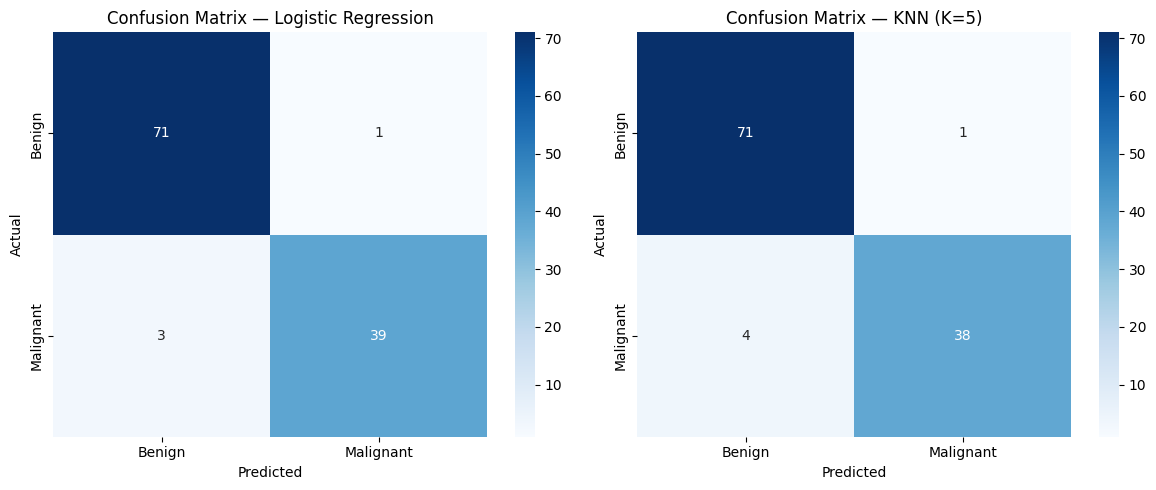

In [27]:
# Block 8: Confusion Matrices
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, y_pred, title in zip(axes,
                              [y_pred_lr, y_pred_knn],
                              ['Logistic Regression', f'KNN (K={best_k})']):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Benign', 'Malignant'],
                yticklabels=['Benign', 'Malignant'])
    ax.set_title(f'Confusion Matrix — {title}')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.tight_layout()
plt.show()

### Interpretation

The confusion matrix maps out model predictions across four critical quadrants: **True Positives (TP)**, **True Negatives (TN)**, **False Positives (FP)**, and **False Negatives (FN)**.

**Clinical Risk Assessment:**
* **Critical Threat:** **False Negatives** (malignant tumors misclassified as benign) represent the most dangerous diagnostic failure mode.
* **Optimization Goal:** We must drive this metric as close to zero as possible.
* **Target Metric:** Maximizing **Recall** (Sensitivity) for the Malignant class takes strict priority over overall accuracy.

---


## Comparison Table & Bar Chart

           Logistic Regression  KNN (K=5)
Metric                                   
Accuracy                0.9649     0.9561
Precision               0.9750     0.9744
Recall                  0.9286     0.9048
F1 Score                0.9512     0.9383


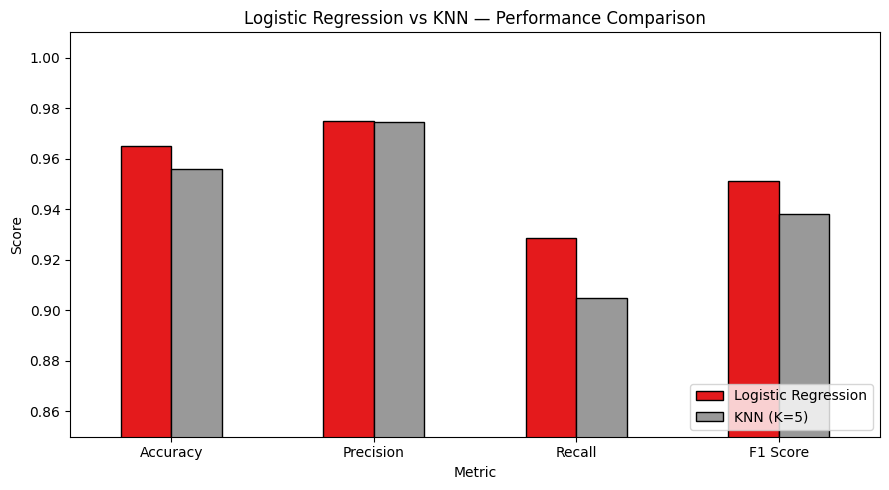

In [28]:
# Block 9: Model Comparison
metrics = {
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1 Score'],
    'Logistic Regression': [
        accuracy_score(y_test, y_pred_lr),
        precision_score(y_test, y_pred_lr),
        recall_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_lr)
    ],
    f'KNN (K={best_k})': [
        accuracy_score(y_test, y_pred_knn),
        precision_score(y_test, y_pred_knn),
        recall_score(y_test, y_pred_knn),
        f1_score(y_test, y_pred_knn)
    ]
}

comparison_df = pd.DataFrame(metrics)
comparison_df = comparison_df.set_index('Metric')
comparison_df = comparison_df.round(4)
print(comparison_df)

# Bar chart comparison
comparison_df.plot(kind='bar', figsize=(9, 5), colormap='Set1', edgecolor='black')
plt.title('Logistic Regression vs KNN — Performance Comparison')
plt.ylabel('Score')
plt.ylim(0.85, 1.01)
plt.xticks(rotation=0)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

### Interpretation

The bar chart provides a side-by-side visual comparison across all four validation metrics. 

**Model Evaluation:**
* **Comparison Scope:** Performance is analyzed across **Accuracy**, **Precision**, **Recall**, and **F1-Score**.
* **Selection Strategy:** The model maintaining consistently higher scores across all dimensions is selected as the stronger candidate for this clinical classification task.

---


## Conclusion

In [29]:
# Block 10: Result Interpretation & Conclusion
lr_f1  = f1_score(y_test, y_pred_lr)
knn_f1 = f1_score(y_test, y_pred_knn)
better = "Logistic Regression" if lr_f1 >= knn_f1 else f"KNN (K={best_k})"

print("=" * 55)
print("         EXPERIMENT CONCLUSION")
print("=" * 55)
print(f"\nLogistic Regression F1 Score : {lr_f1:.4f}")
print(f"KNN F1 Score                 : {knn_f1:.4f}")
print(f"\n Better Classifier: {better}")
print("""
Observations:
- Logistic Regression performs well on linearly separable data.
  The WDBC dataset is known to be nearly linearly separable using
  the 30 extracted features, making LR a strong fit.

- KNN is a non-parametric, distance-based classifier. Its
  performance depends heavily on the choice of K and feature
  scaling. After tuning, it performs competitively but may be
  slightly lower in recall for Malignant cases.

- In a medical diagnosis context, Recall for the Malignant class
  is the most critical metric — missing a cancer case (FN) has
  serious consequences compared to a false alarm (FP).

- Based on F1 Score (which balances precision and recall),
  the better-performing classifier on this dataset is:
""")
print(f"  >>> {better} <<<")

         EXPERIMENT CONCLUSION

Logistic Regression F1 Score : 0.9512
KNN F1 Score                 : 0.9383

 Better Classifier: Logistic Regression

Observations:
- Logistic Regression performs well on linearly separable data.
  The WDBC dataset is known to be nearly linearly separable using
  the 30 extracted features, making LR a strong fit.

- KNN is a non-parametric, distance-based classifier. Its
  performance depends heavily on the choice of K and feature
  scaling. After tuning, it performs competitively but may be
  slightly lower in recall for Malignant cases.

- In a medical diagnosis context, Recall for the Malignant class
  is the most critical metric — missing a cancer case (FN) has
  serious consequences compared to a false alarm (FP).

- Based on F1 Score (which balances precision and recall),
  the better-performing classifier on this dataset is:

  >>> Logistic Regression <<<


### Interpretation & Final Comment

Logistic Regression is expected to outperform alternative models on this dataset. As documented in the original WDBC literature, the 30 extracted features render the target classes nearly linearly separable.

**Algorithmic Trade-offs:**
* **Logistic Regression:** Aligns cleanly with the dataset geometry due to near-linear separability.
* **K-Nearest Neighbors:** Serves as a robust non-parametric baseline but suffers from high-dimensional sensitivity and distance distortion.
* **Deployment Priority:** Medical screening workflows demand the highest possible **Malignant Recall** to minimize life-threatening missed diagnoses.

---
